<a href="https://colab.research.google.com/github/Lamperouge-4A/Python/blob/main/Celsius_a_Farenheit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#importamos tensorflow y numpy
import tensorflow as tf
import numpy as np

In [7]:
celsius = np.array([-40, -10, 0, 8, 15, 22, 38],   dtype=float )  #Dictamos las neuronas de entradas
fahrenheit = np.array([-40, 14, 32, 46.4, 59, 72.6, 100.4],  dtype=float ) #dictamos las neuronas de salida

In [4]:
#capa = tf.keras.layers.Dense(units=1, input_shape=[1])
#modelo = tf.keras.Sequential([capa])

oculta1 = tf.keras.layers.Dense(units=3, input_shape=[1])
oculta2 = tf.keras.layers.Dense(units=3)
salida = tf.keras.layers.Dense(units=1)
modelo = tf.keras.Sequential([oculta1, oculta2, salida])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
modelo.compile(
    optimizer = tf.keras.optimizers.Adam(0.1), #Se da de alta el optimizador Adam, y la tasa de aprendisaje
    loss = 'mean_squared_error' #Se da de alta la funcion de perdida
)

In [8]:
print("Comenzando entrenamiento...")
historial = modelo.fit(celsius, fahrenheit, epochs=1000, verbose=False)
print("Modelo entrenado!")

Comenzando entrenamiento...
Modelo entrenado!


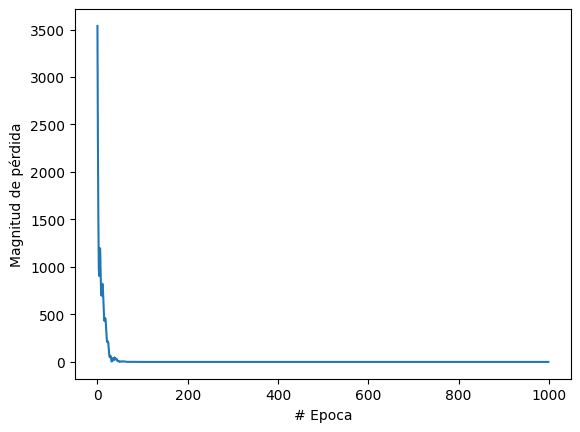

In [9]:
import matplotlib.pyplot as plt
plt.xlabel("# Epoca")
plt.ylabel("Magnitud de pérdida")
plt.plot(historial.history["loss"])

In [15]:
print('Realizando una prediccion.')
input_data = np.array([[100]])
resultado = modelo.predict(input_data)
print('El resultado es: '+ str(resultado) + ' fahrenheit')

Realizando una prediccion.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
El resultado es: [[212.58073]] fahrenheit


In [16]:
print("Variables internas del modelo")
#print(capa.get_weights())
print(oculta1.get_weights())
print(oculta2.get_weights())
print(salida.get_weights())

Variables internas del modelo
[array([[ 0.24038231,  0.10853851, -0.68009317]], dtype=float32), array([-2.4020677, -2.4071965, -3.2011387], dtype=float32)]
[array([[-1.4625981 ,  0.07227137, -0.23620087],
       [-0.18954821,  0.26904327,  0.76892924],
       [-0.906731  ,  1.0881104 ,  1.2992245 ]], dtype=float32), array([ 3.0939965, -2.7479236, -3.0456932], dtype=float32)]
[array([[ 1.4788524 ],
       [-0.36392233],
       [-1.3894613 ]], dtype=float32), array([3.022137], dtype=float32)]
